## 56. Product Recommendation Category 
Dataset: E-commerce dataset 
What to do: Predict product category.

### Importing Libraries and Dataset

In [11]:
import pandas as pd

In [12]:
df = pd.read_csv('ecommerce_10000.csv')

### Performing EDA

In [13]:
df.head()

,OrderID,Product,Category,Brand,Platform,City,Price,Quantity,TotalAmount,Rating,Reviews,OrderDate
0,ORD100000,Samsung Galaxy A14,Electronics,Samsung,Souq,Cairo,16284.02,1,16284.02,1.39,1684,2024-11-11
1,ORD100001,Nike Air Max,Fashion,Nike,Jumia,Alexandria,6645.20,2,13290.40,2.56,3604,2024-06-22
2,ORD100002,Bluetooth Headset,Accessories,JBL,Jumia,Casablanca,8882.92,3,26648.76,4.98,1257,2024-05-27
3,ORD100003,HP Pavilion Laptop,Computers,HP,Souq,Dubai,3665.44,1,3665.44,1.44,662,2024-07-25
4,ORD100004,iPhone 13,Electronics,Apple,Souq,Casablanca,5210.37,2,10420.74,3.73,2424,2024-02-19


In [14]:
df.tail()

,OrderID,Product,Category,Brand,Platform,City,Price,Quantity,TotalAmount,Rating,Reviews,OrderDate
9995,ORD109995,HP Pavilion Laptop,Computers,HP,Jumia,Riyadh,3571.93,1,3571.93,1.05,2154,2024-05-21
9996,ORD109996,Adidas Running Shoes,Fashion,Adidas,Souq,Cairo,2974.55,4,11898.20,2.60,1796,2024-11-27
9997,ORD109997,Adidas Running Shoes,Fashion,Adidas,Amazon,Riyadh,8646.20,1,8646.20,3.20,4001,2024-10-15
9998,ORD109998,T-shirt Cotton,Fashion,Generic,Amazon,Riyadh,4960.53,4,19842.12,3.42,685,2024-04-26
9999,ORD109999,Bluetooth Headset,Accessories,JBL,Jumia,Casablanca,13811.49,5,69057.45,2.84,488,2024-01-15


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   OrderID      10000 non-null  object 
 1   Product      10000 non-null  object 
 2   Category     10000 non-null  object 
 3   Brand        10000 non-null  object 
 4   Platform     10000 non-null  object 
 5   City         10000 non-null  object 
 6   Price        10000 non-null  float64
 7   Quantity     10000 non-null  int64  
 8   TotalAmount  10000 non-null  float64
 9   Rating       10000 non-null  float64
 10  Reviews      10000 non-null  int64  
 11  OrderDate    10000 non-null  object 
dtypes: float64(3), int64(2), object(7)
memory usage: 937.6+ KB


In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,10000.0,10027.986331,5728.261196,105.59,4999.8625,10063.600,14938.43,19999.34
Quantity,10000.0,3.006200,1.415472,1.00,2.0000,3.000,4.00,5.00
TotalAmount,10000.0,30199.572439,23861.789828,113.55,11066.9100,23671.630,44648.58,99993.80
Rating,10000.0,3.005592,1.154845,1.00,2.0100,3.005,4.00,5.00
Reviews,10000.0,2520.072200,1443.849734,0.00,1275.0000,2537.500,3767.00,5000.00


In [17]:
df.isnull().sum()

OrderID        0
Product        0
Category       0
Brand          0
Platform       0
City           0
Price          0
Quantity       0
TotalAmount    0
Rating         0
Reviews        0
OrderDate      0
dtype: int64

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   OrderID      10000 non-null  object 
 1   Product      10000 non-null  object 
 2   Category     10000 non-null  object 
 3   Brand        10000 non-null  object 
 4   Platform     10000 non-null  object 
 5   City         10000 non-null  object 
 6   Price        10000 non-null  float64
 7   Quantity     10000 non-null  int64  
 8   TotalAmount  10000 non-null  float64
 9   Rating       10000 non-null  float64
 10  Reviews      10000 non-null  int64  
 11  OrderDate    10000 non-null  object 
dtypes: float64(3), int64(2), object(7)
memory usage: 937.6+ KB


#### As a part of feature selection

In [29]:
df.drop(columns = ['OrderID','Platform','OrderDate','City'],inplace= True)

In [30]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [31]:
df['Product'] = le.fit_transform(df['Product'])
df['Category'] = le.fit_transform(df['Category'])
df['Brand'] = le.fit_transform(df['Brand'])

### To show correlation of features with each other

In [32]:
c = df.corr(numeric_only = True)

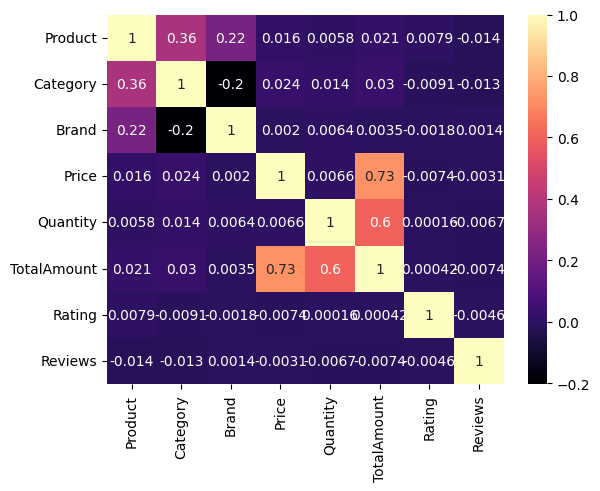

In [33]:
import seaborn as sns 
import matplotlib.pyplot as plt
sns.heatmap(c,annot=True,cmap='magma')
plt.show()

### Splitting the Dataset (80:20)

In [34]:
x = df.drop(columns = 'Category')
y = df['Category']

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=42)

### Training and testing the model

In [37]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()

In [38]:
rfc.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
y_pred = rfc.predict(x_test)

In [40]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [47]:
acc = accuracy_score(y_pred,y_test)
print('Accuracy Score: ', acc * 100)

Accuracy Score:  100.0


In [48]:
cm = confusion_matrix(y_pred,y_test)
print('Confusion Matrix: \n', cm * 100)

Confusion Matrix: 
 [[18100     0     0     0     0]
 [    0 43200     0     0     0]
 [    0     0 61000     0     0]
 [    0     0     0 57400     0]
 [    0     0     0     0 20300]]


In [50]:
cr = classification_report(y_pred,y_test)
print('Classification Report: \n', cr * 100)

Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       181
           1       1.00      1.00      1.00       432
           2       1.00      1.00      1.00       610
           3       1.00      1.00      1.00       574
           4       1.00      1.00      1.00       203

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       181
           1       1.00      1.00      1.00       432
           2       1.00      1.00      1.00       610
           3       1.00      1.00      1.00       574
           4       1.00      1.00      1.00       203

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

## Feature importance

In [56]:
importances = rfc.feature_importances_
feature_importance = pd.DataFrame({'Feature': x.columns,'Importance': importances})
feature_importance.sort_values(by = 'Importance')
print(feature_importance)

       Feature  Importance
0      Product    0.499418
1        Brand    0.473550
2        Price    0.006992
3     Quantity    0.001397
4  TotalAmount    0.006627
5       Rating    0.005882
6      Reviews    0.006134


### Testing usiong an example

In [57]:
df.head()

,Product,Category,Brand,Price,Quantity,TotalAmount,Rating,Reviews
0,5,2,8,16284.02,1,16284.02,1.39,1684
1,4,3,7,6645.20,2,13290.40,2.56,3604
2,1,0,6,8882.92,3,26648.76,4.98,1257
3,3,1,5,3665.44,1,3665.44,1.44,662
4,9,2,1,5210.37,2,10420.74,3.73,2424


In [61]:
predict_this = [[9,1,5210.37,2,10420.74,3.73,2424]]
predicted = rfc.predict(predict_this) # 2
print(predicted)

[2]


C:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
